# Imports

In [1]:
import torch
import torch.nn.functional as F
import gc
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from scipy.io import loadmat
from natsort import natsorted

from dflat.initialize import focusing_lens, multiplexing_mask_orthrand
from dflat.metasurface import reverse_lookup_optimize, load_optical_model
from dflat.propagation import PointSpreadFunction
from dflat.render import hsi_to_rgb, general_convolve

#out_name = "./metasurfaces/"
out_name = "./metasurface_test/"
if not os.path.exists(out_name):
    os.mkdir(out_name)

def create_angular_masks_and_centers(dim, num_sets, radius):
    center = np.array([dim[1] // 2, dim[0] // 2])  # Center coordinates (x, y)
    y, x = np.ogrid[:dim[0], :dim[1]]
    # Compute angles adjusted to start from top-right quadrant
    angles = np.arctan2(-(y - center[1]), x - center[0]) + 2 * np.pi  # atan2 outputs range [-pi, pi]
    angles = (angles + np.pi / 4 ) % (2 * np.pi)  # Shift starting point to top-right quadrant

    # Normalize the angles to fit within the range [0, num_sets)
    sector_indices = np.floor(angles / (2 * np.pi / num_sets)).astype(int)

    masks = []
    center_points = []
    for i in range(num_sets):
        mask = (sector_indices == i).astype(int)
        masks.append(mask)

        # Calculate the midpoint angle for each sector
        mid_angle = (i + 0.5) * (2 * np.pi / num_sets) + 7 * np.pi / 4
        mid_angle %= 2 * np.pi  # Ensure angle is within [0, 2*pi]

        # Calculate opposite angle for centers
        opposite_angle = mid_angle + np.pi
        opposite_angle %= 2 * np.pi  # Normalize angle
        center_x = radius * np.cos(opposite_angle)
        center_y = radius * np.sin(opposite_angle)
        center_points.append((center_x, center_y))

    return masks, center_points


# Choose Lens Configuration 

In [2]:
in_size = [4001, 4001]
in_dx_m=[250e-9, 250e-9]
out_distance = 10e-3

###------------- CHOOSE ONE FROM BELOW ------------###

# config = {    
#     "lens_name": "L1_Lens",
#     "wavelength_set_m": [550e-9],
#     "offsets": [[0,0]],
#     "depth_set_m": [10],
#     "multiplexing_func": multiplexing_mask_orthrand,
#     "in_scale": 1
# }

# config = {    
#     "lens_name": "L2_Lens",
#     "wavelength_set_m": [480e-9, 620e-9],
#     "offsets": [[0,35e-6], [0, -35e-6]],
#     "depth_set_m": [10 for i in range(2)],
#     "multiplexing_func": multiplexing_mask_orthrand,
#     "in_scale": 1
# }

config = {    
    "lens_name": "L4_Lens",
    "wavelength_set_m": [420e-9, 520e-9, 580e-9, 660e-9],
    "offsets": [[-35e-6, 35e-6], [35e-6, 35e-6], [35e-6, -35e-6], [-35e-6, -35e-6]],
    "depth_set_m": [10 for i in range(4)],
    "multiplexing_func": multiplexing_mask_orthrand,
    "in_scale": 1
}

# config = {    
#     "lens_name": "L4s_Lens",
#     "wavelength_set_m": [420e-9, 520e-9, 580e-9, 660e-9],
#     "offsets": [[-210e-6, 210e-6], [210e-6, 210e-6], [210e-6, -210e-6], [-210e-6, -210e-6]],
#     "depth_set_m": [10 for i in range(4)],
#     "multiplexing_func": None, # This lens used a different multiplexing scheme
#     "in_scale": 2
# }

# mask, offsets = create_angular_masks_and_centers(in_size, 8, 40)
# offsets = np.array(offsets) * 1e-6
# config = {    
#     "lens_name": "L8S_Lens",
#     "wavelength_set_m": np.linspace(400e-9, 650e-9, 8),
#     "offsets": offsets,
#     "depth_set_m": [10 for i in range(8)],
#     "multiplexing_func": lambda *args, **kwargs: mask,
#     "in_scale": 1
# }

# Unpacking the config into local variables
locals().update(config)

# Generate the Target Profiles

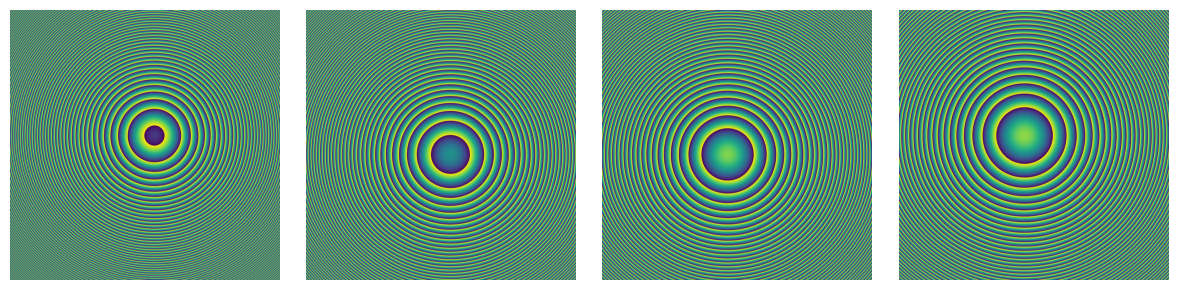

In [3]:
amp, phase, aperture = focusing_lens(
    [sz//in_scale + (sz // in_scale % 2 == 0) for sz in in_size],
    in_dx_m,
    wavelength_set_m,
    depth_set_m,
    offsets,
    out_distance,
    aperture_radius_m=None,
    radial_symmetry=False,
)

nl = len(wavelength_set_m)
fig, ax = plt.subplots(1,nl, figsize=(nl*3,3))
ax = ax if nl > 1 else [ax]
for i in range(nl):
    ax[i].imshow(phase[i], vmin=-np.pi, vmax=np.pi)
    ax[i].axis('off')
plt.tight_layout()

# Reverse Look-Up a Metasurface for each target profile

In [4]:
# Instead of doing a discrete look-up table, DFlat uses a gradient-descent optimization with a pre-trained surrogate model
# This is faster for complex shapes and made the code more generalizable for arbitrary shape dimensions 

using_library = "Nanocylinders_TiO2_U250H600"
load_prev = True
done = False
batch_size = 64000 # Use this if you have limited memory 
if load_prev:
    try: 
        with open(out_name + lens_name + '_lookup.pickle','rb') as handle:
            data = pickle.load(handle)
            shapes = data["shapes"]
        done = True
        print("Loaded previous run saved data")
    except:
        print("Failed to load previous run saved data")
        pass

if not done:
    print("Running reverse look-up")
    list_shapes = []
    list_params = []
    # Each wavelength dependent forcusing profile will get mapped to its own 2D metasurface
    for i in range(amp.shape[0]):
        param, shape, err = reverse_lookup_optimize(
            amp[i:i+1, None, None],
            phase[i:i+1,None, None],
            wavelength_set_m[i:i+1],
            using_library,
            lr=5e-2,
            max_iter=50,
            opt_phase_only=False,
            batch_size=batch_size
            )
        list_shapes.append(shape)
        list_params.append(param)
    
    shapes = np.concatenate(list_shapes, axis=0)
    params = np.concatenate(list_params, axis=0)
    data = {"shapes": shapes, "params": params}

    with open(out_name + lens_name + '_lookup.pickle', 'wb') as handle:
        pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)

Loaded previous run saved data


# Multiplex the lenses into one metasurface

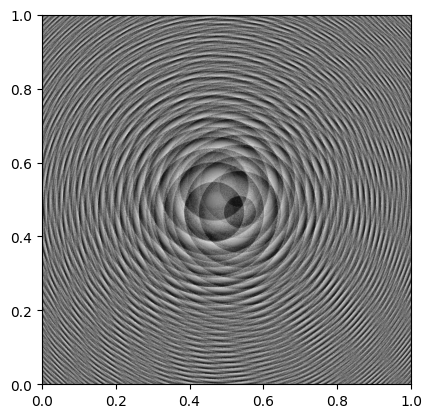

In [5]:
# For the L4S_Lens, we had used a different code!
if multiplexing_func is None:
    # L4s lens used a tiling approach
    mixed_shapes1 = np.concatenate((shapes[1], shapes[0]), axis=0)
    mixed_shapes2 = np.concatenate((shapes[2], shapes[3]), axis=0)
    mixed_shapes = np.concatenate((mixed_shapes1, mixed_shapes2), axis=1).squeeze()[:in_size[0], :in_size[1]]
    mask = None
else:
    nl = len(wavelength_set_m)
    mask = multiplexing_func(nl, in_dx_m, in_dx_m, in_size)
    mixed_shapes = np.sum(shapes[:,:in_size[0],:in_size[1],0]*mask, axis=0)

xvec = np.arange(in_size[0])*in_dx_m[0]*1e3
fig, ax = plt.subplots(1,1)
ax.imshow(mixed_shapes*1e9, cmap='gray', extent=(xvec.min(), xvec.max(), xvec.min(), xvec.max()))
data = {"mixed_shapes": mixed_shapes, "mask": mask, "shapes": shapes}
with open(out_name + lens_name + '_grouped_lens.pickle', 'wb') as handle:
    pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [6]:
with torch.no_grad():
    torch.cuda.empty_cache()
gc.collect() # Python thing
torch.cuda.empty_cache() # PyTorch thing


# Simulate the broadband PSF for the multiplexed metasurface

In [7]:
with torch.no_grad():
    torch.cuda.empty_cache()

sim_wl = np.linspace(400e-9, 700e-9, 31)
model = load_optical_model(using_library).to('cuda')
with torch.no_grad():
    ampl, phase = model(mixed_shapes[None, :, :, None], sim_wl, pre_normalized=False, batch_size=64000)
ampl = ampl[0].cpu() # Drop the batch dimension
phase = phase[0].cpu()
# Note to viewer:
# If you run out of memory, you can loop over wavelengths and remove each intermediate slice from the gpu
# This code works on an rtx3090 but you could also change it for your hardware easily

Target Module: dflat.metasurface.optical_model.NeuralCells
Note: trainable_model key in NeuralCells is deprecated. Model will be set to requires_grad.
Target Module: dflat.metasurface.nn_siren.SirenNet
Target: dflat.metasurface.optical_model.NeuralCells Loading from checkpoint DFlat/Models/Nanocylinders_TiO2_U250H600/model.ckpt as strict=True
Restored dflat.metasurface.optical_model.NeuralCells with 0 missing and 0 unexpected keys


/home/deanhazineh/ssd4tb_mounted/DiffVis/DFlat/dflat/metasurface/load_utils.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu

In [8]:
# Propagating the PSF for the full metasurface can be expensive and require a better GPU than the rtx3090 used in this work
# You get very similar results by downsampling the lens and then propagating the field
ds_factor = 2
ds_in_size = [sz//ds_factor + (sz // ds_factor % 2 == 0) for sz in in_size]
ds_in_dx_m=[250e-9*ds_factor, 250e-9*ds_factor]

ds_ampl = F.interpolate(ampl, size=ds_in_size, mode='area') 
ds_phase_cos = F.interpolate(torch.cos(phase), size=ds_in_size, mode='area')
ds_phase_sin = F.interpolate(torch.sin(phase), size=ds_in_size, mode='area')
ds_phase = torch.atan2(ds_phase_sin, ds_phase_cos)

print("Downsampled size: ",  ds_ampl.shape, ds_phase.shape)

Downsampled size:  torch.Size([1, 31, 2001, 2001]) torch.Size([1, 31, 2001, 2001])


/home/deanhazineh/anaconda3/envs/diffvis/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/deanhazineh/anaconda3/envs/diffvis/lib/python3.11/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


torch.Size([1, 1, 31, 64, 64]) torch.Size([1, 1, 31, 64, 64])


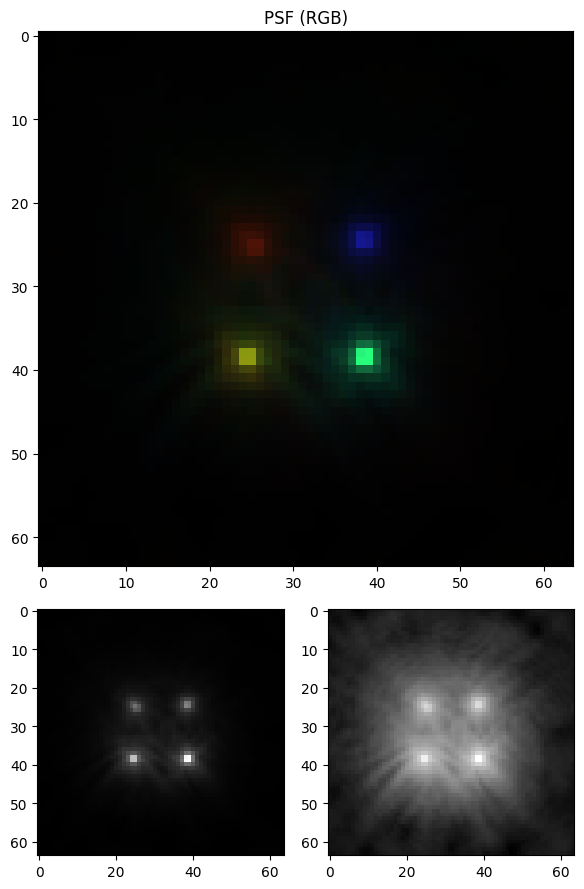

In [9]:
out_size = [64, 64]
#out_size = [32, 32]
out_dx_m = [5e-6, 5e-6]
ps_locs = [[0.0, 0.0, 10]]
PSF = PointSpreadFunction(
    ds_in_size, 
    ds_in_dx_m, 
    out_distance, 
    out_size, 
    out_dx_m,
    sim_wl,
    diffraction_engine='fresnel')

psfi, psfp = PSF(ds_ampl, ds_phase, ps_locs)
print(psfi.shape, psfp.shape)

# Save the PSF
psf_int = psfi.detach().cpu().numpy().squeeze()
psf_phase = psfp.detach().cpu().numpy().squeeze()
psf_rgb = hsi_to_rgb(psf_int[None], sim_wl, process='ideal', tensor_ordering=True).squeeze()
psf_gs = np.sum(psf_int, axis=0)
data = {"psf_int": psf_int, "wl": sim_wl, "psf_rgb": psf_rgb, "psf_gs": psf_gs}

with open(out_name + lens_name + f'_psf_compact{int(out_size[-1])}.pickle', 'wb') as handle:
   pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)

fig = plt.figure(figsize=(6, 9))
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1])
ax1 = fig.add_subplot(gs[0:2, 0:2])
ax2 = fig.add_subplot(gs[2, 0])
ax3 = fig.add_subplot(gs[2, 1])
ax1.imshow(np.transpose(psf_rgb, [1,2,0]))
ax1.set_title("PSF (RGB)")
ax2.imshow(psf_gs, cmap='gray')
ax3.imshow(np.log10(psf_gs), cmap='gray')
plt.tight_layout()
plt.savefig(out_name+lens_name+ f"psf_compact{int(out_size[-1])}.png")

# (optional) View Rendered Image

(31, 482, 512) (31, 64, 64)
(3, 482, 512) (3, 482, 512)


/home/deanhazineh/anaconda3/envs/diffvis/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/deanhazineh/anaconda3/envs/diffvis/lib/python3.11/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


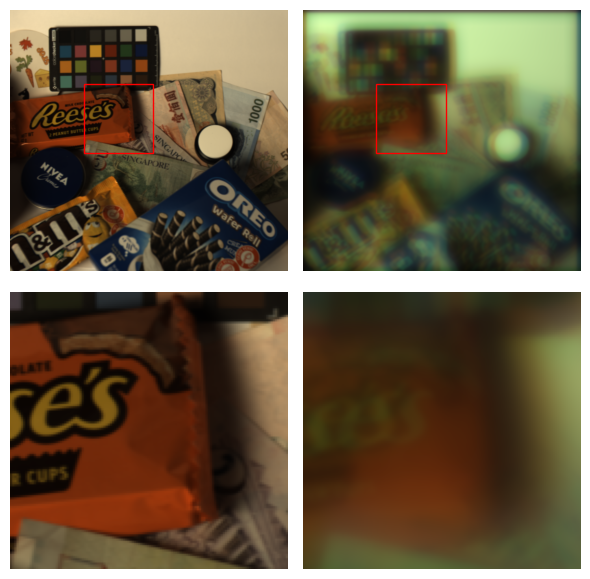

In [12]:
def get_zoomed_in_region(image, center, width):
    x, y = center
    return image[:, y - width // 2:y + width // 2, x - width // 2:x + width // 2]

arad_path = "./datasets/ARAD1k_repackaged/"
fnames = natsorted(os.listdir(arad_path))
f = fnames[543]
datfile = os.path.join(arad_path, f)
hsi = loadmat(datfile)["hsi"]
hsi = np.transpose(hsi, [2,0,1])
hsi = hsi / hsi.max()
rgb = hsi_to_rgb(hsi, sim_wl, tensor_ordering=True)

print(hsi.shape, psf_int.shape)

mhsi = general_convolve(torch.tensor(hsi, dtype=torch.float32, device='cuda'), torch.tensor(psf_int, dtype=torch.float32, device='cuda'), rfft=True).cpu().numpy()
mrgb = hsi_to_rgb(mhsi, sim_wl, gamma=False, demosaic=False, tensor_ordering=True)
print(rgb.shape, mrgb.shape)

zoom_width = 128 
center = (200, 200)  
fig, ax = plt.subplots(2,2, figsize=(6,6))
ax[0,0].imshow(np.transpose(rgb,[1,2,0]))
ax[0,1].imshow(np.transpose(mrgb, [1,2,0]))
ax[0, 0].add_patch(patches.Rectangle((center[0] - zoom_width // 2, center[1] - zoom_width // 2), zoom_width, zoom_width, linewidth=1, edgecolor='r', facecolor='none'))
ax[0, 1].add_patch(patches.Rectangle((center[0] - zoom_width // 2, center[1] - zoom_width // 2), zoom_width, zoom_width, linewidth=1, edgecolor='r', facecolor='none'))

zoomed_rgb = get_zoomed_in_region(rgb, center, zoom_width)
zoomed_mrgb = get_zoomed_in_region(mrgb, center, zoom_width)
ax[1, 0].imshow(np.transpose(zoomed_rgb, [1, 2, 0]))
ax[1, 1].imshow(np.transpose(zoomed_mrgb, [1, 2, 0]))
for axi in ax.flatten():
    axi.axis('off')
plt.tight_layout()
plt.show()